# Key-rate vega & skew: fixed shapes instead of PCA factors

The project's goal is cheap VaR — replacing per-scenario revaluation with a
few greeks — and PCA factors are only one way of compressing the vol surface
into those greeks. This notebook tests the first alternative: plain
desk-style **key-rate sensitivities**, with no fitting anywhere.

- **Level**: each spread's vega from a parallel bump of the smile at its own
  maturity.
- **Skew**: each spread's sensitivity to a moneyness tilt through ATM — +1
  vol pt at 105, −1 at 95, i.e. (m−100)/5 vol pts at moneyness m,
  deliberately **unclamped** into the wings.
- Grouped on 3/6/9/12M knots with tent (linear-interpolation) weights in
  TTM, so the four level sensitivities sum exactly to the net parallel vega
  and there are no bucket seams; TTM < 3M clamps onto the 3M knot.
- **Realized moves, deliberately simple**: the sticky-strike ATM change at
  each knot, and the 90-110 spread change / 4 (so a score of 1 vol pt means
  the literal unit tilt happened). Single-point reads through the pricing
  interpolant — no fit sample, no loadings, and no per-pillar vega scatter
  (hence none of the bucketed-vega side lobes).

The vol P&L estimate is `Σ sens × score` against the headline attribution
target `vol − vol_roll`; VaR runs the same scenario engine as
`historical_var.ipynb` with a key-rate vanna term (the same grouping applied
to `u·vanna`) in place of the bucketed-vanna pairing. Eight numbers per
book; 16 revaluations on the formula-free path (`bumped_key_rate_sens`).

In [1]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vol_pca import load_surfaces, simulate_book, fit_pca
from vol_pca.attribution import independent_attribution
from vol_pca.factors import (estimate_metrics, factor_vega_estimates,
                             sticky_strike_dsigma)
from vol_pca.key_rate import (KNOTS, KR_NAMES, bumped_key_rate_sens,
                              daily_key_rate_sens, key_rate_pnl,
                              key_rate_scores, key_rate_sens,
                              rolling_var_keyrate, tilt)
from vol_pca.surface import MONEYNESS, N_PILLARS, TTM_PILLARS, grid_lookup
from vol_pca.var import (book_speed, build_book, build_scenarios,
                         full_reval_pnl, greeks_pnl, hist_var,
                         scenario_dsigma)

C_FULL, C_TAIL, C_INK, C_GRAY = "#2a78d6", "#e34948", "#0b0b0b", "#898781"
C_ALT = "#b7852e"
C_KNOT = dict(zip((3, 6, 9, 12), ("#2a78d6", "#2e9e77", "#b7852e", "#8a5cd0")))
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "xtick.color": "#898781", "ytick.color": "#898781",
    "text.color": "#0b0b0b", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "legend.frameon": False,
})

sd = load_surfaces("SPX_volSurface 2.csv")
res, bucket_vega, _ = simulate_book(sd)
normal = (res["gap_days"] <= 7).to_numpy()
attr, _ = independent_attribution(sd)
target = (attr["vol"] - attr["vol_roll"]).to_numpy()
dsigma = sticky_strike_dsigma(sd)

dates, sens = daily_key_rate_sens(sd)          # (n-1, 8): 4 level + 4 skew
scores = key_rate_scores(dsigma)               # (n-1, 8) realized moves
est_kr = (sens * scores).sum(axis=1)
print(f"{len(sd)} dates, {normal.sum()} normal P&L days; "
      f"target (vol - vol_roll) total ${target[normal].sum() / 1e6:.1f}M, "
      f"daily std ${target[normal].std() / 1e3:.0f}k")

3141 dates, 3138 normal P&L days; target (vol - vol_roll) total $16.2M, daily std $70k


## The book in key-rate coordinates: mostly a skew position

Grouping is per spread — the tent weight at its own TTM, the tilt at each
leg's own moneyness — so the four level sensitivities sum to the book's net
parallel vega by construction (asserted below against `simulate_book`'s
bucketed vega). The split is the interpretability payoff: net level vega is
the small sign-flipping residual of two large legs, while the **skew
sensitivity is the structural exposure** — short the 100 strike, long the
110 makes the book long the call-wing tilt, ≈ +$0.9M per unit tilt on the
last date, concentrated at the 6–9M knots where the steady-state vega mass
sits.

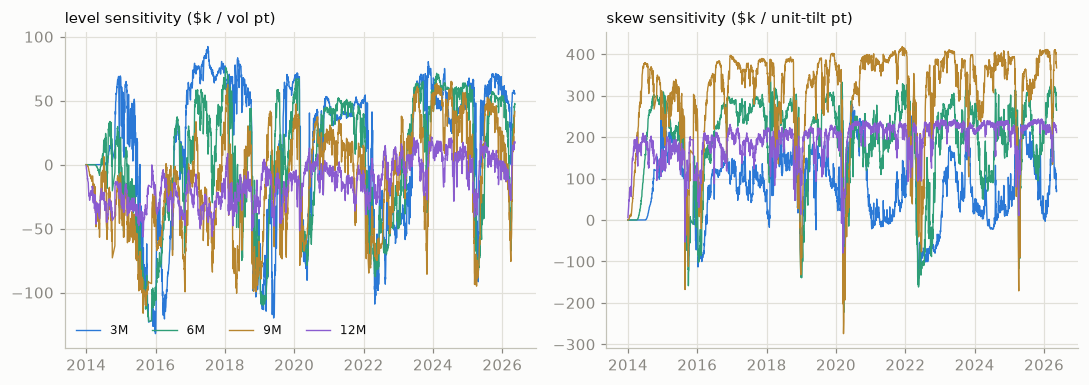

last date ($k per vol pt of unit shape):
         3M     6M     9M    12M    net
level  55.0   47.0   42.0   17.0  161.0
skew   72.0  265.0  367.0  211.0  915.0


In [2]:
assert np.abs(sens[:, :4].sum(1) - bucket_vega.sum(1)).max() < 1e-4  # $ per 1.00 vol

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for j, m in enumerate((3, 6, 9, 12)):
    axes[0].plot(dates, sens[:, j] * 0.01 / 1e3, lw=0.9, color=C_KNOT[m],
                 label=f"{m}M")
    axes[1].plot(dates, sens[:, 4 + j] * 0.01 / 1e3, lw=0.9, color=C_KNOT[m])
axes[0].set_title("level sensitivity ($k / vol pt)", loc="left", fontsize=10)
axes[1].set_title("skew sensitivity ($k / unit-tilt pt)", loc="left", fontsize=10)
axes[0].legend(ncol=4, loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

last = pd.DataFrame(sens[-1].reshape(2, 4) * 0.01 / 1e3,
                    index=["level", "skew"], columns=[f"{m}M" for m in (3, 6, 9, 12)])
last["net"] = last.sum(axis=1)
print("last date ($k per vol pt of unit shape):")
print(last.round(0).to_string())

## Realized moves

Daily stds: ATM level 0.60 / 0.40 / 0.32 / 0.27 vol pts at 3/6/9/12M; the
90-110 spread moves are 4× the skew scores. Level scores are ≥ 0.90
correlated across knots (the term structure moves together) while skew
scores are much less so — collinear inputs are fine here, because both
attribution and historical VaR consume each day's *joint* draw of the eight
moves rather than treating them as independent risks.

                lvl_3m  lvl_6m  lvl_9m  lvl_12m  skw_3m  skw_6m  skw_9m  skw_12m
std (vol pts)    0.599   0.399   0.319    0.271   0.090   0.054   0.039    0.033
mean (pts/day)   0.024   0.019   0.017    0.015  -0.007  -0.002  -0.001    0.000
cross-knot score corr: level min 0.90, skew min 0.32


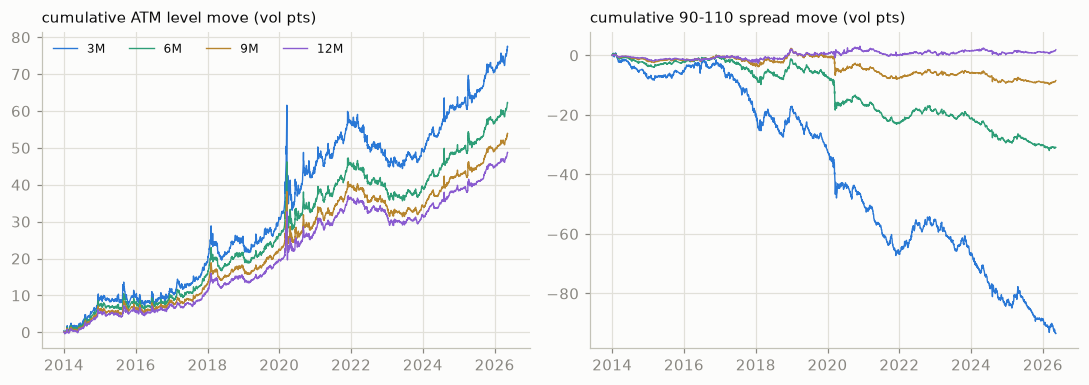

In [3]:
st = pd.DataFrame({"std (vol pts)": scores[normal].std(0) * 100,
                   "mean (pts/day)": scores[normal].mean(0) * 100},
                  index=KR_NAMES).T
print(st.round(3).to_string())
cl = np.corrcoef(scores[normal, :4].T)
cs = np.corrcoef(scores[normal, 4:].T)
print(f"cross-knot score corr: level min {cl[np.triu_indices(4, 1)].min():.2f}, "
      f"skew min {cs[np.triu_indices(4, 1)].min():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
for j, m in enumerate((3, 6, 9, 12)):
    axes[0].plot(dates, np.cumsum(scores[:, j]) * 100, lw=0.9,
                 color=C_KNOT[m], label=f"{m}M")
    axes[1].plot(dates, np.cumsum(scores[:, 4 + j]) * 4 * 100, lw=0.9,
                 color=C_KNOT[m])
axes[0].set_title("cumulative ATM level move (vol pts)", loc="left", fontsize=10)
axes[1].set_title("cumulative 90-110 spread move (vol pts)", loc="left", fontsize=10)
axes[0].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

## Attribution: 8 fixed shapes vs fitted factors

Against the fixed-strike vol target on normal days the key-rate estimate
reaches **R² 0.71 — below vega-weighted PCA with just three fitted factors
(0.81)**, let alone the like-for-like span dimension k=8 (0.93). The error
tails split the story: typical days are fine (p95 error $48k vs k=3's
$50k), but the worst days are twice as bad (max $1.4M vs $0.7M — all March
2020). Cumulatively the estimate books $10.3M of the $16.2M target: level
contributes +$14.9M and skew −$4.6M (the carry drag of being long the
call-wing tilt), nearly uncorrelated day to day.

In [4]:
vega_w = np.abs(bucket_vega[normal]).mean(axis=0)
model = fit_pca(dsigma, fit_mask=normal, weights=vega_w)
ests, _, _ = factor_vega_estimates(bucket_vega, dsigma, model,
                                   [3, 5, 8, 10, model.n_components])
named = {f"PCA k={k}": v for k, v in ests.items()}
named["key-rate (8)"] = est_kr

print("=== all normal days ===")
print(estimate_metrics(target, named, mask=normal).round(4).to_string())
big = normal & (np.abs(target) >= np.quantile(np.abs(target[normal]), 0.9))
print(f"\n=== big-move days (top decile |target|, n={big.sum()}) ===")
print(estimate_metrics(target, named, mask=big).round(4).to_string())
print("\n|error| tails ($k, normal days):")
for name in ("key-rate (8)", "PCA k=3", "PCA k=8", "PCA k=10"):
    err = np.abs(target - named[name])[normal]
    print(f"  {name:12s} p95 {np.percentile(err, 95) / 1e3:5.0f}   "
          f"p99 {np.percentile(err, 99) / 1e3:5.0f}   max {err.max() / 1e3:5.0f}")

=== all normal days ===
                  r2    corr        rmse
estimate                                
PCA k=3       0.8108  0.9028  30366.7878
PCA k=5       0.8559  0.9279  26470.8198
PCA k=8       0.9267  0.9637  18873.4362
PCA k=10      0.9343  0.9677  17872.5377
PCA k=104     0.9852  0.9928   8500.1221
key-rate (8)  0.7050  0.8597  37911.7222

=== big-move days (top decile |target|, n=314) ===
                  r2    corr         rmse
estimate                                 
PCA k=3       0.8454  0.9210   78174.0956
PCA k=5       0.8584  0.9299   74375.3404
PCA k=8       0.9295  0.9653   52281.1755
PCA k=10      0.9357  0.9687   49946.9506
PCA k=104     0.9828  0.9917   26055.2435
key-rate (8)  0.7082  0.8658  106940.7705

|error| tails ($k, normal days):
  key-rate (8) p95    48   p99   122   max  1399
  PCA k=3      p95    50   p99   120   max   663
  PCA k=8      p95    22   p99    62   max   497
  PCA k=10     p95    22   p99    60   max   516


cumulative: target $16.2M, estimate $10.3M = level +14.9M + skew -4.6M;  corr(level, skew) -0.04


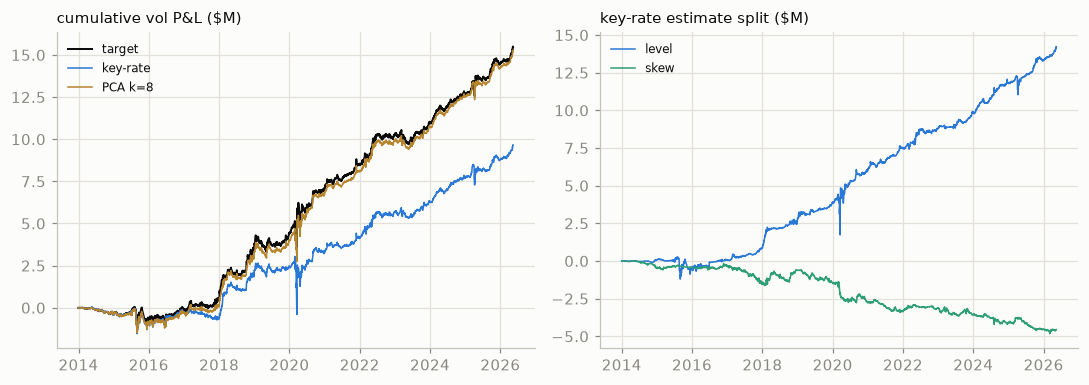

In [5]:
lvl = (sens[:, :4] * scores[:, :4]).sum(1)
skw = (sens[:, 4:] * scores[:, 4:]).sum(1)
print(f"cumulative: target ${target[normal].sum() / 1e6:.1f}M, estimate "
      f"${est_kr[normal].sum() / 1e6:.1f}M = level {lvl[normal].sum() / 1e6:+.1f}M "
      f"+ skew {skw[normal].sum() / 1e6:+.1f}M;  "
      f"corr(level, skew) {np.corrcoef(lvl[normal], skw[normal])[0, 1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharex=True)
axes[0].plot(dates, np.cumsum(target) / 1e6, lw=1.3, color=C_INK, label="target")
axes[0].plot(dates, np.cumsum(est_kr) / 1e6, lw=1.0, color=C_FULL, label="key-rate")
axes[0].plot(dates, np.cumsum(named["PCA k=8"]) / 1e6, lw=1.0, color=C_ALT,
             label="PCA k=8")
axes[0].set_title("cumulative vol P&L ($M)", loc="left", fontsize=10)
axes[0].legend(fontsize=8)
axes[1].plot(dates, np.cumsum(lvl) / 1e6, lw=1.0, color=C_FULL, label="level")
axes[1].plot(dates, np.cumsum(skw) / 1e6, lw=1.0, color="#2e9e77", label="skew")
axes[1].set_title("key-rate estimate split ($M)", loc="left", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## What's missing is curvature (and read width), not the short end

2020-03-16 is the anatomy lesson. The sticky-strike move was +10–17 vol pts
at the short end with a violently non-monotonic smile shape — the 110–120
columns moved *half* as much as either the 90s or the 140s. A level+tilt
span cannot represent that: the ATM / 90-110 reads scored it as a huge level
rise with mild skew, and the crisis book's short-vega key-rate profile
turned that into **−$1.26M against a +$140k truth** — the same day that
breaks the PCA projection ($0.5M error at k=10), now failing through the
score reads instead of the weights.

In-sample least squares on the residual measures the missing shapes: four
butterfly reads `(90 + 110 − 2·ATM)/2` lift R² **0.705 → 0.790**; a wider
80-120 skew read alone reaches 0.750; a short-end ATM read (0.08y − 3M)
adds *nothing*. So the third shape worth having is **curvature per knot**,
and the skew read should widen as the book's strikes drift — both are just
extra rows of the same sens/score machinery.

In [6]:
resid = target - est_kr
worst = np.argsort(-np.abs(np.where(normal, resid, 0.0)))[:6]
print("worst key-rate days ($k):")
print(pd.DataFrame({"target": target[worst] / 1e3, "key-rate": est_kr[worst] / 1e3,
                    "resid": resid[worst] / 1e3,
                    "PCA k=10 err": (target - named["PCA k=10"])[worst] / 1e3},
                   index=pd.Index(res.index[worst], name="date")).round(0).to_string())

# extra reads: butterfly at the knots, wide 80-120 skew, short-end ATM
dummy = np.zeros((len(TTM_PILLARS), len(MONEYNESS)))
def reads(mons):
    q = np.repeat(KNOTS, len(mons))
    _, w_idx, w = grid_lookup(dummy, q, np.tile(mons, len(KNOTS)),
                              want_weights=True)
    R = np.zeros((len(q), N_PILLARS))
    np.add.at(R, (np.arange(len(q))[:, None], w_idx), w)
    return R
R3 = reads(np.array([90.0, 100.0, 110.0]))
fly = dsigma @ ((R3[0::3] + R3[2::3] - 2 * R3[1::3]) / 2).T
R2m = reads(np.array([80.0, 120.0]))
wide = dsigma @ ((R2m[1::2] - R2m[0::2]) / 8).T
short = (dsigma[:, 6] - scores[:, 0])[:, None]        # (0.08y ATM) - lvl_3m

base_r2 = 1 - resid[normal].var() / target[normal].var()
print(f"\nkey-rate R2 {base_r2:.3f}; in-sample LS gains from candidate reads:")
for name, X in (("+ butterfly (4 knots)", fly), ("+ wide 80-120 skew", wide),
                ("+ short-end ATM", short),
                ("+ butterfly + short-end", np.column_stack([fly, short]))):
    b = np.linalg.lstsq(X[normal], resid[normal], rcond=None)[0]
    r2 = 1 - (resid[normal] - X[normal] @ b).var() / target[normal].var()
    print(f"  {name:26s} R2 {r2:.3f}")

i = np.where(res.index == np.datetime64("2020-03-16"))[0][0]
print("\n2020-03-16 sticky-strike dsigma (vol pts):")
print(pd.DataFrame(dsigma[i].reshape(8, 13) * 100,
                   index=[f"{t:.2f}y" for t in TTM_PILLARS],
                   columns=[int(m) for m in MONEYNESS]).round(1).to_string())
print(f"scores (pts): lvl {np.round(scores[i, :4] * 100, 1)}  "
      f"skw {np.round(scores[i, 4:] * 100, 2)}")
print(f"sens ($k/pt): lvl {np.round(sens[i, :4] * 0.01 / 1e3)}  "
      f"skw {np.round(sens[i, 4:] * 0.01 / 1e3)}")

worst key-rate days ($k):
            target  key-rate   resid  PCA k=10 err
date                                              
2020-03-16   140.0   -1259.0  1399.0         516.0
2020-03-09   310.0     -88.0   397.0          97.0
2020-03-23   383.0     686.0  -302.0        -255.0
2020-03-17  -341.0     -44.0  -297.0        -302.0
2020-03-11    13.0    -279.0   292.0          95.0
2025-04-04  -345.0    -626.0   282.0         210.0

key-rate R2 0.705; in-sample LS gains from candidate reads:
  + butterfly (4 knots)      R2 0.790
  + wide 80-120 skew         R2 0.750
  + short-end ATM            R2 0.705
  + butterfly + short-end    R2 0.792

2020-03-16 sticky-strike dsigma (vol pts):
        50    60    70    80    90    95    100   105   110   120   130   140   150
0.08y  10.7  17.0  15.8  13.5  11.6  11.3   9.8   9.7  11.9  13.4  15.0  17.9  20.8
0.17y  14.7  13.2  11.9  10.9   9.7   9.6  10.1  11.4  12.3  14.4  17.9  20.8  24.3
0.25y   5.4   8.4  11.3  12.2  10.2   9.8  10.0  10.2   7

## VaR, as-of 2026-05-12: the single-date read flatters it

Same scenarios and non-vol terms as the PCA path — only the vol and vanna
terms change. At the quantile the key-rate projection lands **within 1% of
full reval**, better than greeks k=3 or k=5 — but scenario-level accuracy
(R² 0.91, worst-1% error $56k) sits between k=3 and k=5, and this project
has already caught two single-date verdicts (the cube term, the vanna
ablation) that reversed on the rolling history. The rolling test below
settles it. The formula-free budget: 16 shape revaluations (validated
against the closed-form grouping below), plus the same spot/rate/div
stencils as the bump path — the same budget class as PCA k=5's 32.

                VaR99 hedged ($k) hedged gap  VaR99 raw ($k) raw gap
method                                                              
full reval                  183.2                     1235.8        
greeks k=3                  165.7      -9.6%          1275.1   +3.2%
greeks k=5                  190.2      +3.8%          1265.8   +2.4%
greeks k=10                 184.9      +0.9%          1249.6   +1.1%
key-rate                    182.0      -0.7%          1294.1   +4.7%
key-rate +cube              182.1      -0.6%          1296.0   +4.9%

tail diagnostics (hedged):
  greeks k=3   R2 0.952   worst-1% |err| $58k   tail overlap 25/31
  greeks k=10  R2 0.950   worst-1% |err| $23k   tail overlap 28/31
  key-rate     R2 0.910   worst-1% |err| $56k   tail overlap 22/31


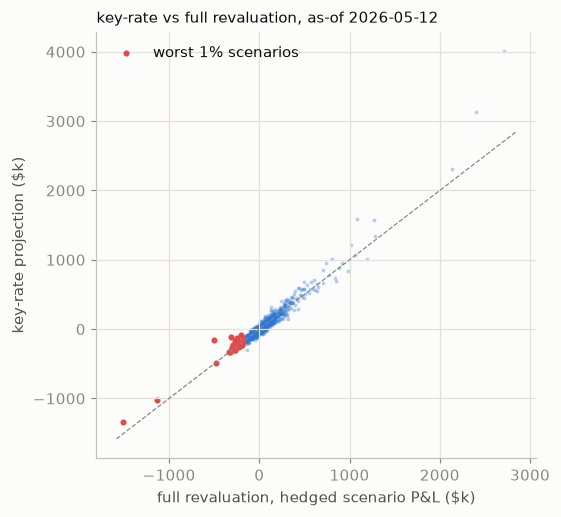

bumped (16 revals) vs closed-form sens: max rel err 5.6e-04


In [7]:
book = build_book(sd)
scen = build_scenarios(sd, book, mask=normal)
pnl_full = full_reval_pnl(book, scen)
dS = book.spot * (scen.ratio - 1.0)
hedge = book.net_delta * dS
full_h = pnl_full - hedge
ds_scen = scenario_dsigma(book, scen)

model_ri = fit_pca(sticky_strike_dsigma(sd, include_roll=True),
                   fit_mask=normal, weights=vega_w)
ks = [3, 5, 10]
est_g, _ = greeks_pnl(book, scen, model_ri, ks, dsigma_scen=ds_scen)
est_krv, parts = key_rate_pnl(book, scen, dsigma_scen=ds_scen)
cube = book_speed(book) / 6.0 * dS**3

rows = [("full reval", pnl_full)] + [(f"greeks k={k}", est_g[k]) for k in ks]
rows += [("key-rate", est_krv), ("key-rate +cube", est_krv + cube)]
tab = pd.DataFrame(
    [{"method": n, "VaR99 hedged ($k)": hist_var(p - hedge) / 1e3,
      "hedged gap": hist_var(p - hedge) / hist_var(full_h) - 1,
      "VaR99 raw ($k)": hist_var(p) / 1e3,
      "raw gap": hist_var(p) / hist_var(pnl_full) - 1} for n, p in rows]
).set_index("method")
for c in ("hedged gap", "raw gap"):
    tab[c] = tab[c].map(lambda g: "" if abs(g) < 1e-12 else f"{g:+.1%}")
print(tab.round(1).to_string())

worst_s = np.argsort(full_h)[:len(scen) // 100]
print("\ntail diagnostics (hedged):")
for name, e in [("greeks k=3", est_g[3]), ("greeks k=10", est_g[10]),
                ("key-rate", est_krv)]:
    err = full_h - (e - hedge)
    o = np.argsort(e - hedge)[:len(worst_s)]
    print(f"  {name:12s} R2 {1 - err.var() / full_h.var():.3f}   "
          f"worst-1% |err| ${np.abs(err[worst_s]).mean() / 1e3:.0f}k   "
          f"tail overlap {len(set(worst_s) & set(o))}/{len(worst_s)}")

fig, ax = plt.subplots(figsize=(5.2, 4.8))
ax.scatter(full_h / 1e3, (est_krv - hedge) / 1e3, s=6, alpha=0.35,
           color=C_FULL, lw=0)
ax.scatter(full_h[worst_s] / 1e3, (est_krv - hedge)[worst_s] / 1e3, s=16,
           color=C_TAIL, lw=0, label="worst 1% scenarios")
lims = np.array([full_h.min(), full_h.max()]) / 1e3 * 1.05
ax.plot(lims, lims, color=C_GRAY, lw=0.8, ls="--")
ax.set_xlabel("full revaluation, hedged scenario P&L ($k)")
ax.set_ylabel("key-rate projection ($k)")
ax.legend(loc="upper left")
ax.set_title("key-rate vs full revaluation, as-of 2026-05-12", loc="left",
             fontsize=10)
plt.tight_layout()
plt.show()

ana = key_rate_sens(book.units * book.vega0, book.strike / book.spot * 100.0,
                    book.ttm)
bmp = bumped_key_rate_sens(book, eps=0.01)     # the literal 1-vol-pt bumps
print(f"bumped (16 revals) vs closed-form sens: max rel err "
      f"{np.abs(bmp - ana).max() / np.abs(ana).max():.1e}")

## Rolling backtest: the mirage reverses, again

Over all 2,889 as-of books (a greeks-only pass — full reval joined from the
cached PCA backtest) the key-rate hedged VaR99 gap is **mean 7.4% / median
6.5% with the cube term** (8.3 / 7.1 without) vs 5.6% for PCA k=4+cube and
4.7% for k=10+cube — better than PCA on only about a third of days, and
above 10% on 29% of them. The crisis tail is **unchanged**: 2020-03-16
understates −67% (PCA −61%). The fixed-shape span does not fix the
displaced-book failure, because that failure was never weight truncation
alone — the realized crisis move is curvature-shaped, outside level+tilt no
matter how the pillars are weighted. Raw VaR gaps run 3.3% mean vs 0.9%
(k=10). So the gate / partial-reval screen stays necessary under this basis
too.

=== hedged VaR99 gaps, 2,889 as-of dates ===
        mean |gap|  median |gap|  >10%  worst  2020-03-16
g3c_h          6.7           5.4  20.5  -56.1       -56.1
g4c_h          5.6           4.3  14.9  -62.6       -62.6
g5c_h          5.7           4.3  15.4  -65.7       -65.7
g10c_h         4.7           2.8  11.4  -61.0       -61.0
kr_h           8.3           7.1  34.3  -66.9       -66.9
krc_h          7.4           6.5  29.2  -66.9       -66.9

=== raw VaR99 gaps ===
          mean |gap|  median |gap|  >10%  worst  2020-03-16
g4c_raw          2.1           1.8   0.3  -39.9       -39.9
g10c_raw         0.9           0.6   0.4  -37.5       -37.5
kr_raw           3.3           2.8   0.7  -41.8       -41.8
key-rate+cube better than g4c on 36% of days
key-rate+cube better than g10c on 30% of days


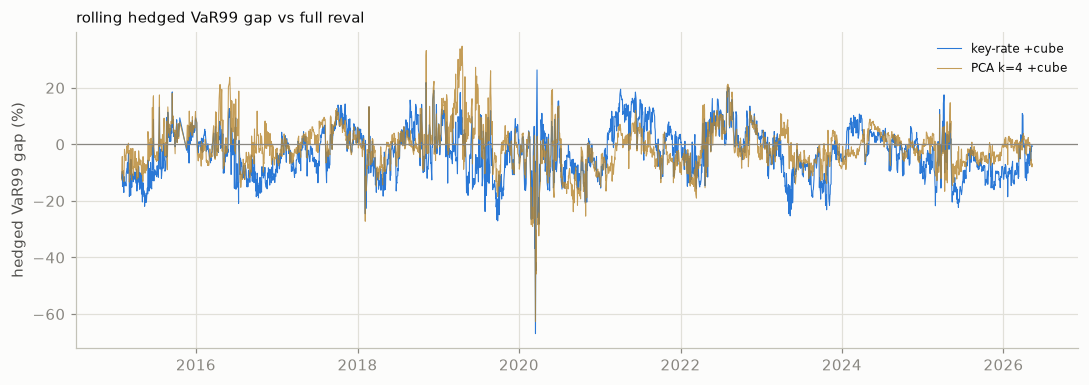

In [8]:
kr_csv = pathlib.Path("data/var_rolling_keyrate.csv")
if kr_csv.exists():
    kroll = pd.read_csv(kr_csv, index_col=0, parse_dates=True)
else:                                  # ~1 min on many cores, greeks only
    kroll = rolling_var_keyrate(sd, start=252, mask=normal)
    kroll.to_csv(kr_csv)
roll = pd.read_csv("data/var_rolling.csv", index_col=0,
                   parse_dates=True).join(kroll)

def gapstats(col, bench):
    g = roll[col] / roll[bench] - 1
    return {"mean |gap|": g.abs().mean(), "median |gap|": g.abs().median(),
            ">10%": (g.abs() > 0.10).mean(), "worst": g.min(),
            "2020-03-16": g.loc["2020-03-16"]}

htab = pd.DataFrame({c: gapstats(c, "full_h") for c in
                     ("g3c_h", "g4c_h", "g5c_h", "g10c_h", "kr_h", "krc_h")}).T
rtab = pd.DataFrame({c: gapstats(c, "full_raw") for c in
                     ("g4c_raw", "g10c_raw", "kr_raw")}).T
print("=== hedged VaR99 gaps, 2,889 as-of dates ===")
print((htab * 100).round(1).to_string())
print("\n=== raw VaR99 gaps ===")
print((rtab * 100).round(1).to_string())
gk = (roll["krc_h"] / roll["full_h"] - 1).abs()
for ref in ("g4c_h", "g10c_h"):
    gr = (roll[ref] / roll["full_h"] - 1).abs()
    print(f"key-rate+cube better than {ref[:-2]} on {(gk < gr).mean():.0%} of days")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(roll.index, (roll["krc_h"] / roll["full_h"] - 1) * 100, lw=0.7,
        color=C_FULL, label="key-rate +cube")
ax.plot(roll.index, (roll["g4c_h"] / roll["full_h"] - 1) * 100, lw=0.7,
        color=C_ALT, alpha=0.8, label="PCA k=4 +cube")
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.set_ylabel("hedged VaR99 gap (%)")
ax.set_title("rolling hedged VaR99 gap vs full reval", loc="left", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Takeaways

- **The framework works and is lean**: eight desk-interpretable numbers, no
  fit sample, no weights to go stale, exact net-vega additivity, 16
  revaluations formula-free (matching closed form to ~6e-4), and the book
  reads naturally — a call-spread book is mostly a **skew** book (≈ +$0.9M
  per unit tilt vs $160k/pt net level vega on the last date).
- **At this simplicity level it costs real accuracy**: attribution R² 0.71
  vs 0.81 for PCA k=3 (0.93 at the like-for-like k=8); rolling hedged
  VaR99 mean |gap| 7.4% vs 5.6% (PCA k=4+cube) in the same reval-budget
  class. Fitted loadings earn their keep.
- **Single-date VaR tests mislead — for the third time in this project**:
  −0.7% as-of 2026-05-12, mean 7.4% over the rolling history.
- **The crisis failure is basis-independent**: −67% on the COVID-peak book
  vs PCA's −61% — realized crisis moves are curvature, which neither
  refitted weights nor a level+tilt span contains. The strike-histogram
  gate / dual-screened partial reval keep owning that tail.
- **Measured headroom for round two**: a butterfly shape per knot lifts the
  in-sample ceiling 0.705 → 0.790; widening the skew read to 80-120 gets
  0.750 alone; the short end adds nothing. Both are two more rows of the
  same sens/score machinery — worth trying before any hybrid with fitted
  factors.